In [1]:
import os, sys

proj_path = os.path.join(sys.prefix, 'share', 'proj')

os.environ["PROJ_DATA"] = proj_path
os.environ["PROJ_LIB"] = proj_path

import pyproj
pyproj.datadir.set_data_dir(proj_path)
print("PROJ Data Directory:", pyproj.datadir.get_data_dir())
### if pyproj still unable to set PROJ databse path:
# %micromamba update pyproj proj geopandas -c conda-forge


import rasterio
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm

from mpl_toolkits.axes_grid1 import make_axes_locatable
import mplcursors
from mpl_toolkits.mplot3d import Axes3D


from IPython.display import display

from pyproj import Geod

from pathlib import Path

import rioxarray

from shapely.geometry import box
import cartopy.io.shapereader as shpreader

from scipy import ndimage
from scipy.ndimage import gaussian_filter

import geopandas as gpd

/Users/user/micromamba/envs/universal/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


PROJ Data Directory: /Users/user/micromamba/envs/universal/share/proj


In [2]:
### establish unit conversions

FT_PER_M = 3.28084
FT_PER_NMI = 6076.11549
M_PER_NMI = 1852.0

In [3]:
### make plots interactive
# %matplotlib widget

### make plots static 
%matplotlib inline

In [4]:
cwd = Path.cwd()

project_dir = cwd.parent
data_root_dir = project_dir / "data"

print(cwd)
print(project_dir)
print(data_root_dir)

/Users/user/Desktop/desktop/General/projects/mid_atlantic_ridge_bathymetry_analysis-main
/Users/user/Desktop/desktop/General/projects
/Users/user/Desktop/desktop/General/projects/data


In [5]:
### data paths

### bathymetry DEM (a raster of seafloor) from GEBCO : https://download.gebco.net/
dem_file = data_root_dir / "mid_atlantic_ridge_bathymetry_analysis" / "GEBCO_09_Apr_2024_b42e1d2f0d25" / "gebco_2023_n50.0_s10.0_w-50.0_e-20.0.tif"
### hydrothermal vents SHP (vector of points) from Pacific Data Hub : https://pacificdata.org/data/dataset/global-distribution-of-hydrothermal-vent-fields-2020-interr830ebd2e-4b05-4d53-af3e-e251c8c16d41
vents_file = data_root_dir / "mid_atlantic_ridge_bathymetry_analysis" / "Global_2020_HydrothermalVents_InterRidgeVentsDatabasev3.4" / "Global_2020_HydrothermalVents_InterRidgeVentsDatabasev3.4.shp"

In [ ]:
# ### read shapefile as pandas df using geopandas
# vents_df = gpd.read_file(vents_file, encoding="latin1")
# print(type(vents_df)) 
# print(vents_df.head())
# ### inspect geometry coordinates
# print(vents_df[['geometry']].head())

# ### read raster as pandas df using rioxarray, alternatively might use rasterio+numpy 
# ### convert 3d array (band, y, x) to pandas df
# dem_df = (rioxarray.open_rasterio(dem_file)).to_dataframe(name="depth").reset_index()
# print(dem_df.head())


### open and run DEM statistics
dem = (
    rioxarray.open_rasterio(dem_file, masked=True)
    .isel(band=0, drop=True)
)
print(dem) ### DEM is about 70 million pixels
print("\nCRS:", dem.rio.crs)
print("\nResolution:", dem.rio.resolution())
print("\nMinimum (m):", float(dem.min()))
print("\nMaximum (m):", float(dem.max()))
print("\nMean (m):", float(dem.mean()))






### logic for finding seafloor slope and magnitude

### extract latitude, longitude and depth from raster
lon = dem.x.values
lat = dem.y.values
depth = dem.values.astype(float)

### calculate first derivative in depth-units-per-degree
dz_dlat, dz_dlon = np.gradient(depth, lat, lon)

### initialize wgs84 ellipsoid model for geodetic distance calculations
geod = Geod(ellps="WGS84")

### calculate meters per degree of longitude at each latitude (accounting for polar meridian convergence)
_, _, m_per_deg_lon = geod.inv(
    np.zeros_like(lat),
    lat,
    np.ones_like(lat),
    lat,
)
### calulcate meters per degree of latitude at each latitude (1-degree span centered on each latitude point)
_, _, m_per_deg_lat = geod.inv(
    np.zeros_like(lat),
    lat - 0.5,
    np.zeros_like(lat),
    lat + 0.5,
)

### convert gradients from depth per degree to dimensionless slope ratio (meters vertical rise per meter horizontal run)
dz_dy = dz_dlat / m_per_deg_lat[:, None]
dz_dx = dz_dlon / m_per_deg_lon[:, None]

### calculate dimensionless slope ratio from x and y components, this is the magnitude
slope_ratio = np.hypot(dz_dx, dz_dy) 

### convert slope ratio to physical slope angle
slope_angle_deg = np.degrees(np.arctan(slope_ratio))

### find top percentiles of seafloor slope
valid_slope = slope_angle_deg[
    np.isfinite(slope_angle_deg)
]
print("\nseafloor slope percentiles:")

for percentile in [50, 75, 90, 95, 99, 99.5, 99.2]:
    angle = np.percentile(valid_slope, percentile)

    print(f"{percentile:>5.1f}th percentile: {angle:.2f}°")

### slope angles are useful for knowing how much the slope changes but the magnitude may inform of how much the vertical component changes with horizontal distance 




<xarray.DataArray 'elevation' (y: 9600, x: 7200)> Size: 276MB
[69120000 values with dtype=float32]
Coordinates:
  * x        (x) float64 58kB -50.0 -49.99 -49.99 -49.99 ... -20.01 -20.01 -20.0
  * y        (y) float64 77kB 50.0 49.99 49.99 49.99 ... 10.01 10.01 10.01 10.0
    crs      int64 8B 0
Attributes: (12/62)
    lat#axis:                        Y
    lat#long_name:                   latitude
    lat#sdn_parameter_name:          Latitude north
    lat#sdn_parameter_urn:           SDN:P01::ALATZZ01
    lat#sdn_uom_name:                Degrees north
    lat#sdn_uom_urn:                 SDN:P06::DEGN
    ...                              ...
    sdn_uom_name:                    Metres
    sdn_uom_urn:                     SDN:P06::ULAA
    standard_name:                   height_above_mean_sea_level
    units:                           m
    scale_factor:                    1.0
    add_offset:                      0.0

CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["

ERROR 1: PROJ: internal_proj_identify: /Users/user/micromamba/envs/universal/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 5 whereas a number >= 6 is expected. It comes from another PROJ installation.



Minimum (m): -7690.0

Maximum (m): 2676.0

Mean (m): -4207.1767578125

seafloor slope percentiles:
 50.0th percentile: 1.57°
 75.0th percentile: 3.59°
 90.0th percentile: 7.29°
 95.0th percentile: 10.65°
 99.0th percentile: 18.78°
 99.5th percentile: 22.11°
 99.9th percentile: 29.20°


In [66]:

### coordinate bounds used for subplots focusing on Azores islands
azores_bounds = (-32.0, -23.0, 35.5, 41.0)
cape_verde_bounds = (-27.0, -21.0, 13.0, 19.0)

### get outline of azores using cartopy shp reader, azores is interesting because it sits on and around the Atlantic mid-ocean-ridge (MOR) and contains +ve elevation
admin1_path = shpreader.natural_earth(
    resolution="10m", category="cultural", name="admin_1_states_provinces",
)
admin1 = list(shpreader.Reader(admin1_path).records())

admin0_path = shpreader.natural_earth(
    resolution="10m", category="cultural", name="admin_0_countries"
)
admin0 = list(shpreader.Reader(admin0_path).records())

azores = next(r.geometry for r in admin1 if r.attributes["name"] == "Azores")
cape_verde = next(r.geometry for r in admin0 if r.attributes["NAME"] == "Cabo Verde")

### function to plot outline
def plot_outline(ax, geometry,color="#1a1a2e", **kwargs):
    polygons = geometry.geoms if geometry.geom_type == "MultiPolygon" else [geometry]
    for polygon in polygons:
        ax.plot(*polygon.exterior.xy,color=color, **kwargs)

In [72]:
### bathymetric transition detector


coarsen_factor = 2
### multiscales in nautical mile blocks
scales_nmi = np.array([1, 2, 4, 8, 16, 32], dtype=float)
threshold_ft = 3000.0

lon_a = lon
lat_a = lat

# depth_a = np.where(
#     np.isfinite(depth) & (depth < 0),
#     depth,
#     np.nan,
# )

### cap land elevations at sea level while retaining submarine depth
depth_a = np.where(
    np.isfinite(depth),
    np.minimum(depth, 0.0),
    np.nan,
)

### A 15-arcsecond cell is approximately 0.25 nmi north-south , using smoothing factor v , resolution becomes r = 0.25*v
### reduce the working grid to approximately  r nmi resolution
height = depth_a.shape[0] // coarsen_factor * coarsen_factor
width = depth_a.shape[1] // coarsen_factor * coarsen_factor

depth_c = np.nanmean(
    depth_a[:height, :width].reshape(
        height // coarsen_factor,
        coarsen_factor,
        width // coarsen_factor,
        coarsen_factor,
    ),
    axis=(1, 3),
)

lat_c = lat_a[:height].reshape(
    -1,
    coarsen_factor,
).mean(axis=1)

lon_c = lon_a[:width].reshape(
    -1,
    coarsen_factor,
).mean(axis=1)

### calculate physical grid spacing
lat_mid = float(np.nanmedian(lat_c))

_, _, cell_x_m = geod.inv(
    lon_c[0],
    lat_mid,
    lon_c[1],
    lat_mid,
)

_, _, cell_y_m = geod.inv(
    0.0,
    lat_c[0],
    0.0,
    lat_c[1],
)

cell_x_nmi = cell_x_m / M_PER_NMI
cell_y_nmi = cell_y_m / M_PER_NMI

### calculate distance represented by one degree at each latitude
_, _, m_per_deg_lon = geod.inv(
    np.zeros_like(lat_c),
    lat_c,
    np.ones_like(lat_c),
    lat_c,
)

_, _, m_per_deg_lat = geod.inv(
    np.zeros_like(lat_c),
    lat_c - 0.5,
    np.zeros_like(lat_c),
    lat_c + 0.5,
)

### prepare the seafloor for normalized gaussian smoothing, ignore very small-scale local features
valid = np.isfinite(depth_c)
values = np.where(valid, depth_c, 0.0)
weights = valid.astype(float)

max_response_ft = np.zeros(
    depth_c.shape,
    dtype=np.float32,
)

best_scale_nmi = np.full(
    depth_c.shape,
    np.nan,
    dtype=np.float32,
)

best_gradient = np.full(
    depth_c.shape,
    np.nan,
    dtype=np.float32,
)

### retain complete response and gradient fields for every analysis scale
cube_shape = (
    scales_nmi.size,
    *depth_c.shape,
)

response_cube_ft = np.full(
    cube_shape,
    np.nan,
    dtype=np.float32,
)

gradient_x_cube = np.full(
    cube_shape,
    np.nan,
    dtype=np.float32,
)

gradient_y_cube = np.full(
    cube_shape,
    np.nan,
    dtype=np.float32,
)

### calculate transition strength across spatial scales
for scale_index, scale_nmi in enumerate(scales_nmi):
    sigma = (
        scale_nmi / cell_y_nmi,
        scale_nmi / cell_x_nmi,
    )

    smooth_values = ndimage.gaussian_filter(
        values,
        sigma=sigma,
        mode="nearest",
    )

    smooth_weights = ndimage.gaussian_filter(
        weights,
        sigma=sigma,
        mode="nearest",
    )

    smooth_depth = np.divide(
        smooth_values,
        smooth_weights,
        out=np.full_like(smooth_values, np.nan),
        where=smooth_weights > 0,
    )

    dz_dlat, dz_dlon = np.gradient(
        smooth_depth,
        lat_c,
        lon_c,
    )

    dz_dx = dz_dlon / m_per_deg_lon[:, None]
    dz_dy = dz_dlat / m_per_deg_lat[:, None]

    gradient = np.hypot(
        dz_dx,
        dz_dy,
    )

    response_ft = (
        np.sqrt(2.0 * np.pi)
        * scale_nmi
        * FT_PER_NMI
        * gradient
    )

    response_cube_ft[scale_index] = response_ft.astype(
        np.float32,
        copy=False,
    )

    gradient_x_cube[scale_index] = dz_dx.astype(
        np.float32,
        copy=False,
    )

    gradient_y_cube[scale_index] = dz_dy.astype(
        np.float32,
        copy=False,
    )

    stronger = (
        np.isfinite(response_ft)
        & (response_ft > max_response_ft)
    )

    max_response_ft[stronger] = response_ft[stronger]
    best_scale_nmi[stronger] = scale_nmi
    best_gradient[stronger] = gradient[stronger]

### convert the greatest gradient to vertical feet per nautical mile
best_gradient_ft_per_nmi = (
    best_gradient * FT_PER_NMI
)
### convert the same gradient to slope angle
best_slope_angle_deg = np.degrees(
    np.arctan(best_gradient)
)

### retain only major transitions
major_transition = np.ma.masked_less(
    max_response_ft,
    threshold_ft,
)

valid_transition = max_response_ft[
    max_response_ft >= threshold_ft
]


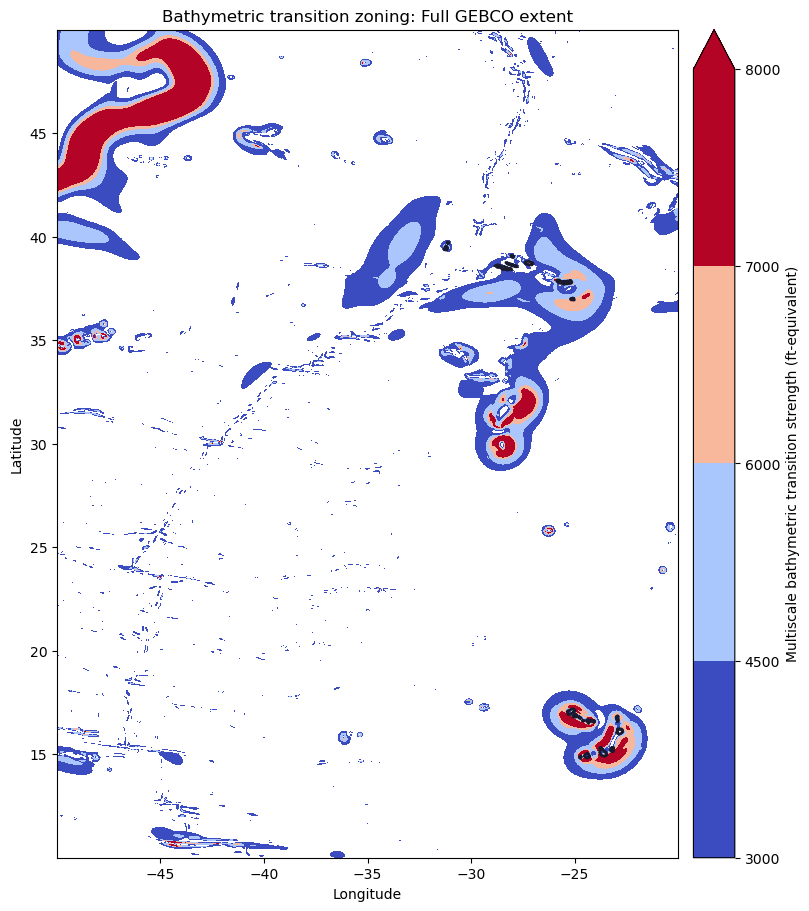

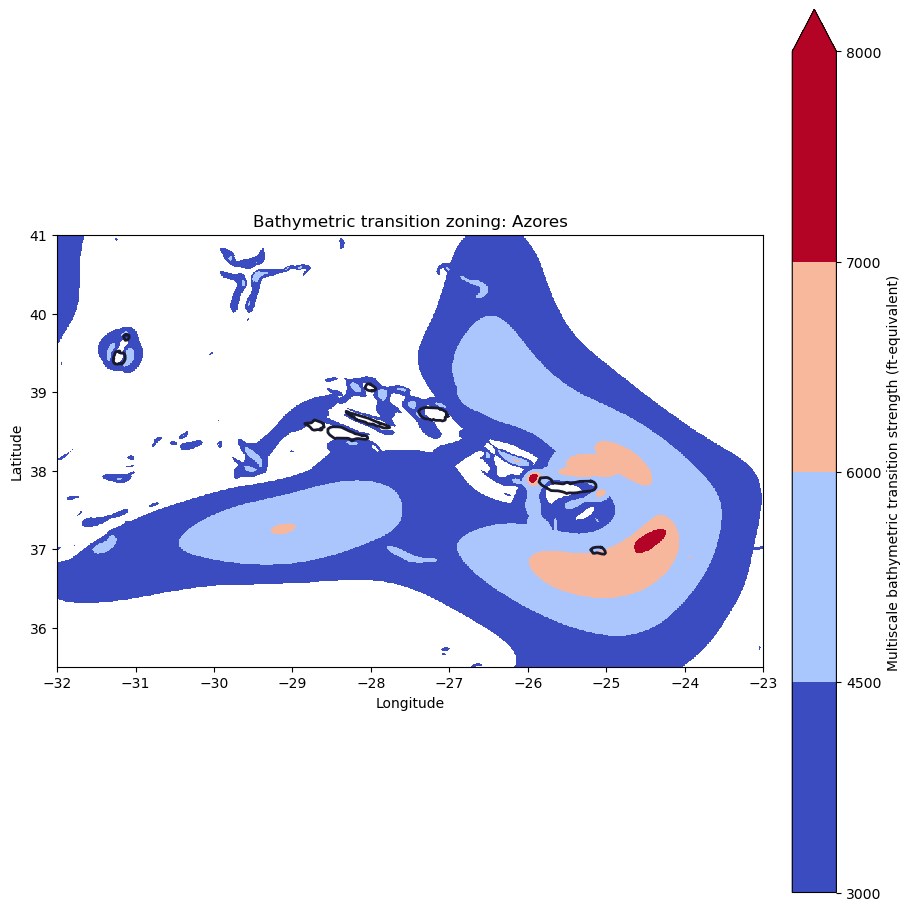

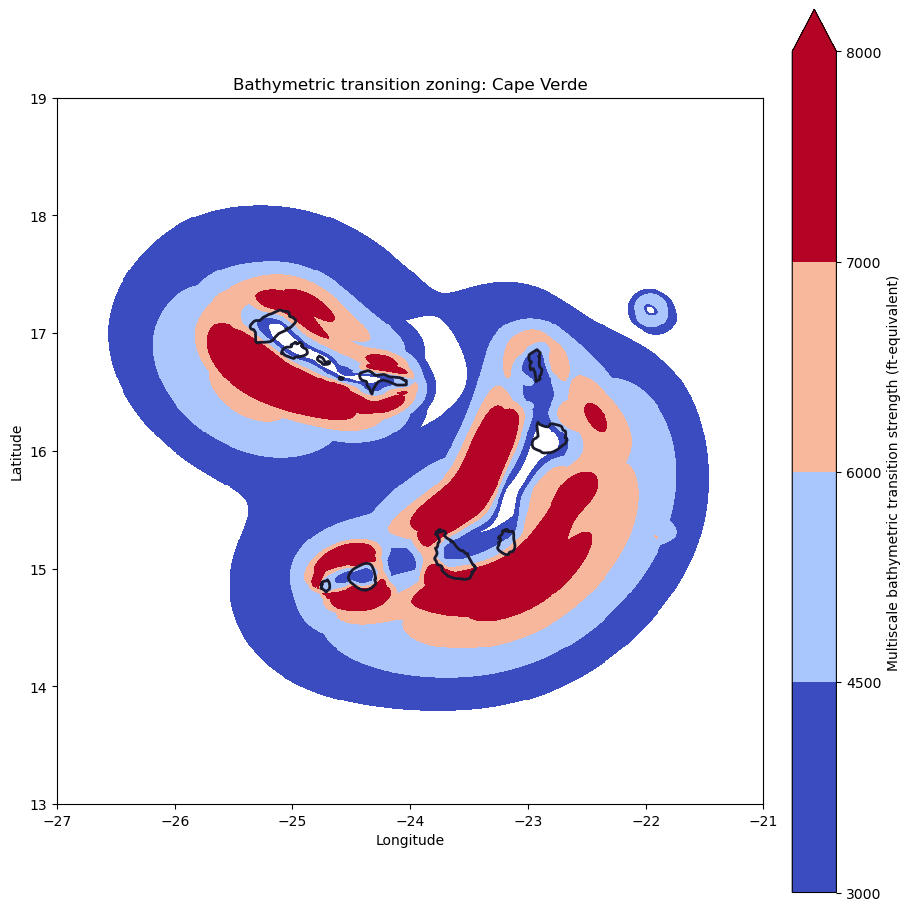

In [ ]:
### plotting transition strength 


bounds = np.array([
    3000,
    4500,
    6000,
    7000,
    8000,
])

cmap = plt.get_cmap(
    "coolwarm",
    len(bounds) - 1,
).copy()

cmap.set_bad(
    color="white",
    alpha=0.0,
)

norm = mcolors.BoundaryNorm(
    bounds,
    cmap.N,
    clip=True,
)

origin = "upper" if lat_c[0] > lat_c[-1] else "lower"

transition_areas = [
    (
        "Full GEBCO extent",
        (lon_c.min(), lon_c.max(), lat_c.min(), lat_c.max()),
        (azores, cape_verde),
    ),
    (
        "Azores",
        azores_bounds,
        (azores,),
    ),
    (
        "Cape Verde",
        cape_verde_bounds,
        (cape_verde,),
    ),
]

for area_name, area_bounds, outlines in transition_areas:
    fig, ax = plt.subplots(
        figsize=(9, 9),
        constrained_layout=True,
    )

    image = ax.imshow(
        major_transition,
        extent=[
            lon_c.min(),
            lon_c.max(),
            lat_c.min(),
            lat_c.max(),
        ],
        origin=origin,
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )

    for geometry in outlines:
        plot_outline(
            ax,
            geometry,
            linewidth=2,
            zorder=3,
        )

    ax.set_xlim(
        area_bounds[0],
        area_bounds[1],
    )

    ax.set_ylim(
        area_bounds[2],
        area_bounds[3],
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_title(
        f"Bathymetric transition zoning: {area_name}"
    )

    cbar = fig.colorbar(
        image,
        ax=ax,
        ticks=bounds,
        spacing="uniform",
        pad=0.02,
        extend="max",
    )

    cbar.set_label(
        "Multiscale bathymetric transition strength (ft-equivalent)"
    )

    plt.show()

One can see red colored, high transition zones, which represent areas with >7000 ft of bathymetry transition. These fall around the Newfoundland Continental shelf edge (NW), around the Azores (E), the Meteor and Cruiser tablemounts and surrounding seamounts (S of Azores), and around Cape Verde (SE). 

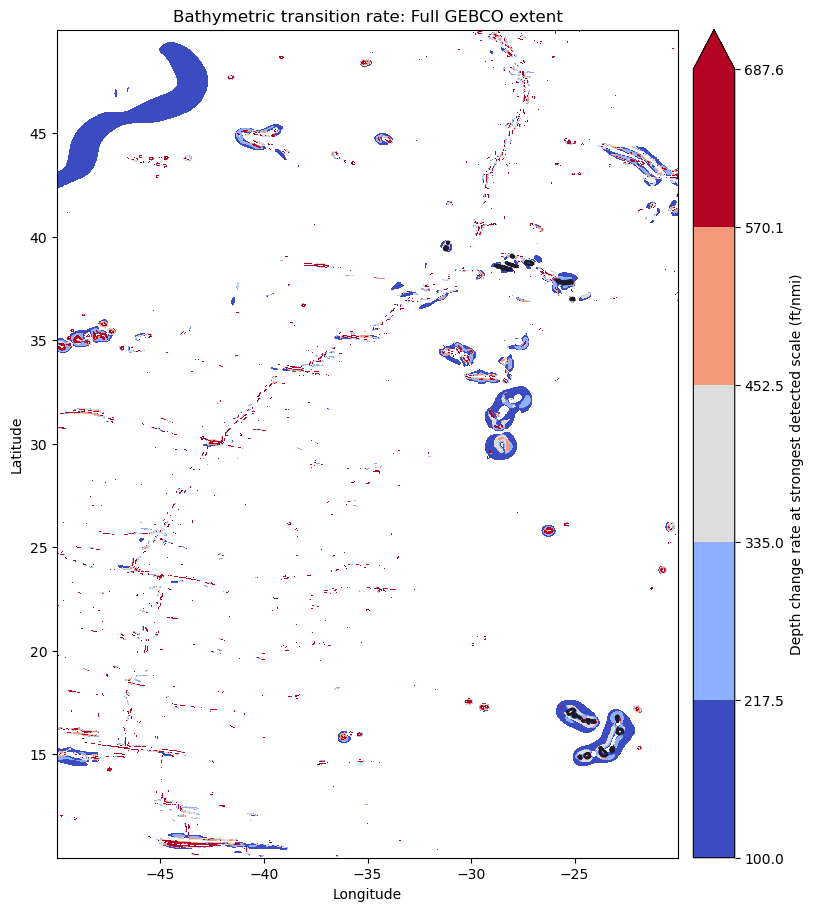

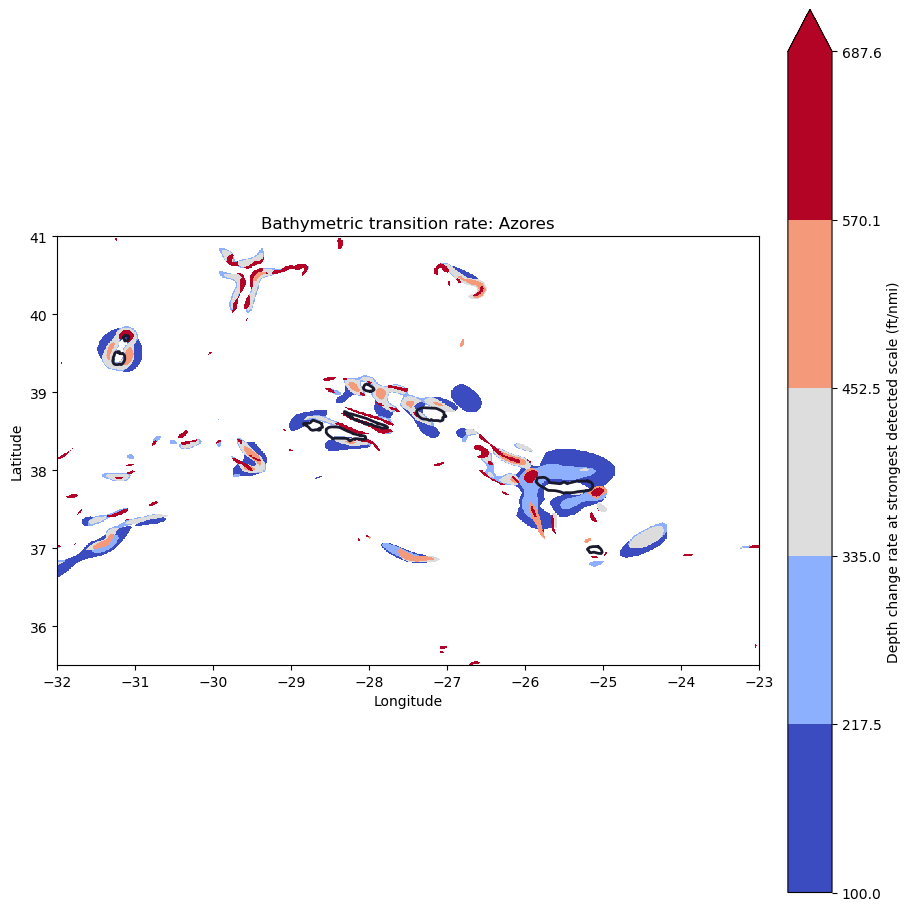

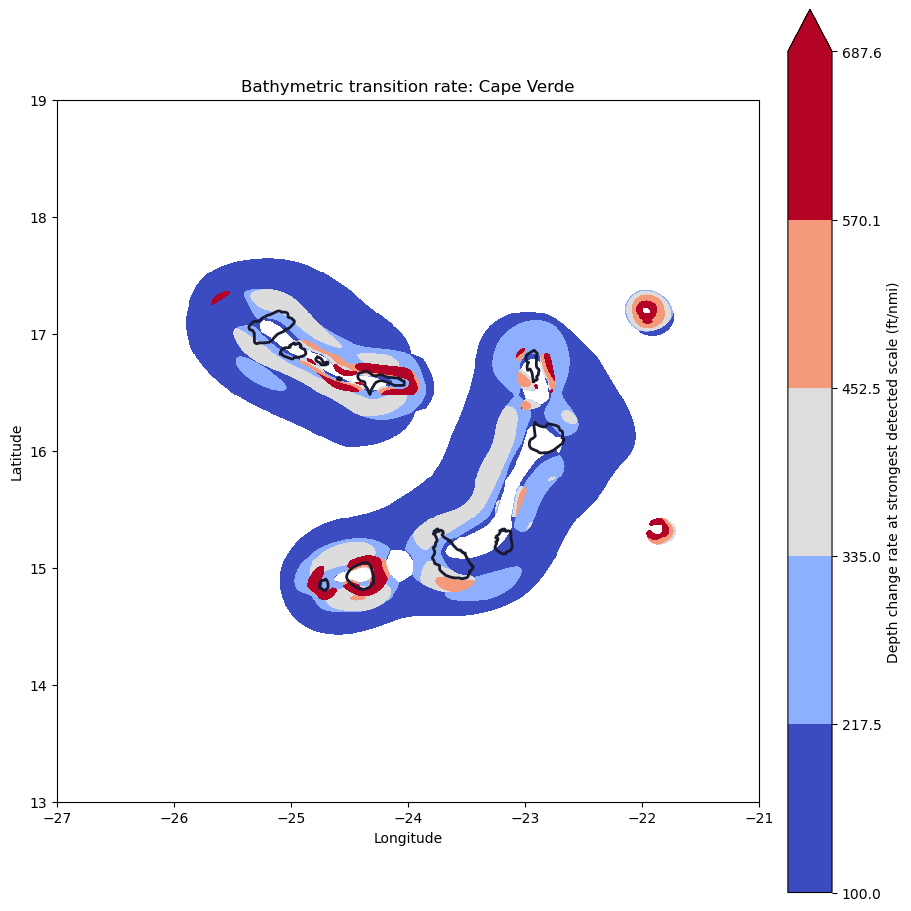

In [ ]:
### plot transition rate as three standalone figures

rate_threshold = 100.0

gradient_rate = np.ma.masked_where(
    ~np.isfinite(best_gradient_ft_per_nmi)
    | (max_response_ft < threshold_ft)
    | (best_gradient_ft_per_nmi < rate_threshold),
    best_gradient_ft_per_nmi,
)

valid_rate = best_gradient_ft_per_nmi[
    np.isfinite(best_gradient_ft_per_nmi)
    & (max_response_ft >= threshold_ft)
    & (best_gradient_ft_per_nmi >= rate_threshold)
]

rate_upper = np.percentile(
    valid_rate,
    90,
)

rate_bounds = np.linspace(
    rate_threshold,
    rate_upper,
    6,
)

rate_cmap = plt.get_cmap(
    "coolwarm",
    len(rate_bounds) - 1,
).copy()

rate_cmap.set_bad(
    color="white",
    alpha=0.0,
)

rate_norm = mcolors.BoundaryNorm(
    rate_bounds,
    rate_cmap.N,
    clip=True,
)

origin = "upper" if lat_c[0] > lat_c[-1] else "lower"

transition_areas = [
    (
        "Full GEBCO extent",
        (lon_c.min(), lon_c.max(), lat_c.min(), lat_c.max()),
        (azores, cape_verde),
    ),
    (
        "Azores",
        azores_bounds,
        (azores,),
    ),
    (
        "Cape Verde",
        cape_verde_bounds,
        (cape_verde,),
    ),
]



### plotting

for area_name, area_bounds, outlines in transition_areas:
    fig, ax = plt.subplots(
        figsize=(9, 9),
        constrained_layout=True,
    )

    image = ax.imshow(
        gradient_rate,
        extent=[
            lon_c.min(),
            lon_c.max(),
            lat_c.min(),
            lat_c.max(),
        ],
        origin=origin,
        cmap=rate_cmap,
        norm=rate_norm,
        interpolation="nearest",
    )

    for geometry in outlines:
        plot_outline(
            ax,
            geometry,
            linewidth=2,
            zorder=3,
        )

    ax.set_xlim(
        area_bounds[0],
        area_bounds[1],
    )

    ax.set_ylim(
        area_bounds[2],
        area_bounds[3],
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_title(
        f"Bathymetric transition rate: {area_name}"
    )

    cbar = fig.colorbar(
        image,
        ax=ax,
        ticks=rate_bounds,
        spacing="uniform",
        pad=0.02,
        extend="max",
    )

    cbar.set_label(
        "Depth change rate at strongest detected scale (ft/nmi)"
    )

    plt.show()

Formigas grid location: -24.6042°, 36.9042°
Formigas transition strength: 6,738 ft
Formigas depth-change rate: 168 ft/nmi
Formigas characteristic scale: 16 nmi
Formigas slope angle: 1.58°
formigas multiscale response:
   1 nmi:    2,924 ft  (0.43 of peak)
   2 nmi:    4,294 ft  (0.64 of peak)
   4 nmi:    4,789 ft  (0.71 of peak)
   8 nmi:    5,578 ft  (0.83 of peak)
  16 nmi:    6,738 ft  (1.00 of peak)
  32 nmi:    6,637 ft  (0.98 of peak)


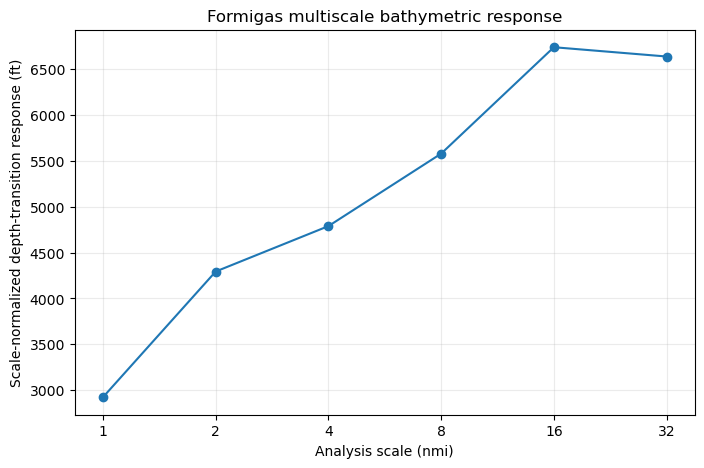

In [ ]:
### formigas diagnostic

formigas_hole_lon = -24.6
formigas_hole_lat = 36.9

### locate formigas hole on the coarsened analysis grid
formigas_col = np.abs(
    lon_c - formigas_hole_lon
).argmin()

formigas_row = np.abs(
    lat_c - formigas_hole_lat
).argmin()

### report the actual grid location used
print(
    "Formigas grid location:",
    f"{lon_c[formigas_col]:.4f}°,",
    f"{lat_c[formigas_row]:.4f}°",
)

print(
    "Formigas transition strength:",
    f"{max_response_ft[formigas_row, formigas_col]:,.0f} ft",
)

print(
    "Formigas depth-change rate:",
    f"{best_gradient_ft_per_nmi[formigas_row, formigas_col]:,.0f} ft/nmi",
)

print(
    "Formigas characteristic scale:",
    f"{best_scale_nmi[formigas_row, formigas_col]:.0f} nmi",
)

print(
    "Formigas slope angle:",
    f"{best_slope_angle_deg[formigas_row, formigas_col]:.2f}°",
)


### inspect the complete scale response at the formigas reference point
formigas_response_ft = response_cube_ft[
    :,
    formigas_row,
    formigas_col,
]

formigas_peak_ft = np.nanmax(
    formigas_response_ft
)

formigas_relative_response = (
    formigas_response_ft
    / formigas_peak_ft
)

print("formigas multiscale response:")

for scale_nmi, response_ft, relative_response in zip(
    scales_nmi,
    formigas_response_ft,
    formigas_relative_response,
):
    print(
        f"{scale_nmi:>4.0f} nmi: "
        f"{response_ft:>8,.0f} ft  "
        f"({relative_response:.2f} of peak)"
    )

fig, ax = plt.subplots(
    figsize=(8, 5),
)

ax.plot(
    scales_nmi,
    formigas_response_ft,
    marker="o",
)

ax.set_xscale(
    "log",
    base=2,
)

ax.set_xticks(
    scales_nmi
)

ax.set_xticklabels(
    [f"{scale:g}" for scale in scales_nmi]
)

ax.set_xlabel(
    "Analysis scale (nmi)"
)

ax.set_ylabel(
    "Scale-normalized depth-transition response (ft)"
)

ax.set_title(
    "Formigas multiscale bathymetric response"
)

ax.grid(
    alpha=0.25
)

plt.show()


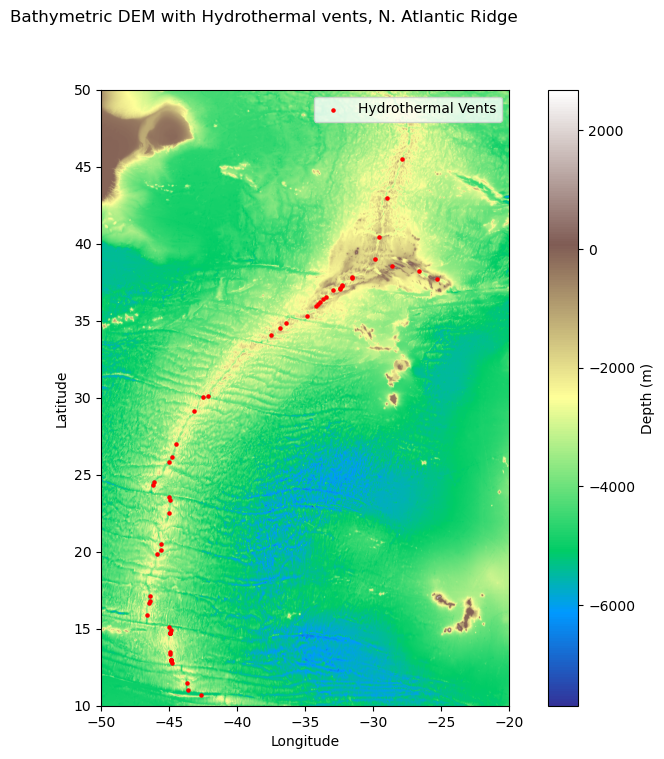

In [16]:
### visualization of DEM and SHP together

### load DEM raster
with rasterio.open(dem_file) as src:
    dem = src.read(1)
    transform = src.transform
    dem_bounds = src.bounds

### plot DEM as is
fig = plt.figure(figsize=(10, 8))
plt.imshow(dem, cmap='terrain', extent=[transform[2], transform[2] + dem.shape[1] * transform[0], transform[5] + dem.shape[0] * transform[4], transform[5]])
plt.colorbar(label='Depth (m)')
fig.suptitle('Bathymetric DEM with Hydrothermal vents, N. Atlantic Ridge', ha='center')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

### load hydrothermal vents data
vents_data = gpd.read_file(vents_file, encoding='latin1')

### filter hydrothermal vents data based on DEM extent
bbox = box(dem_bounds.left, dem_bounds.bottom, dem_bounds.right, dem_bounds.top)
vents_data_filtered = vents_data[vents_data.geometry.within(bbox)]

### plot filtered hydrothermal vents on top of DEM
vents_plot = vents_data_filtered.plot(ax=plt.gca(), color='red', markersize=5, label='Hydrothermal Vents')

plt.legend()
plt.show()


In [ ]:
### select columns
selected_columns = vents_data_filtered[["Latitude", "Longitude", "Maximum Te", "Name ID", "Ocean"]]

### set maximum number of rows to display
pd.set_option('display.max_rows', len(selected_columns))

display(selected_columns)

### define DEM bounds 
dem_left, dem_bottom, dem_right, dem_top = dem_bounds.left, dem_bounds.bottom, dem_bounds.right, dem_bounds.top

### filter dataframe for rows within the bounds of the DEM
vents_data_filtered = vents_data[(vents_data['Longitude'] >= dem_left) & 
                                 (vents_data['Longitude'] <= dem_right) &
                                 (vents_data['Latitude'] >= dem_bottom) &
                                 (vents_data['Latitude'] <= dem_top)]

### filter dataframe for rows where the "Ocean" column matches "N. Atlantic"
atlantic_data = vents_data_filtered[vents_data_filtered['Ocean'].str.strip().str.lower() == 'n. atlantic']

### select columns
selected_columns = atlantic_data[["Latitude", "Longitude", "Maximum Te", "Name ID", "Ocean"]]

### set the maximum number of rows to display
pd.set_option('display.max_rows', len(selected_columns))

,Latitude,Longitude,Maximum Te,Name ID,Ocean
18,36.3833,-33.6500,NaN,AMAR,N. Atlantic
22,12.9733,-44.8633,355.0,Ashadze-1,N. Atlantic
23,12.9917,-44.9067,NaN,Ashadze-2,N. Atlantic
24,12.9860,-44.8610,NaN,Ashadze-3,N. Atlantic
25,12.9700,-44.8500,NaN,Ashadze-4,N. Atlantic
41,29.1700,-43.1717,365.0,Broken Spur,N. Atlantic
44,37.8000,-31.5333,300.0,Bubbylon,N. Atlantic
102,38.2300,-26.6300,121.0,Don Joao de Castro Bank,N. Atlantic
211,38.5500,-28.6000,35.0,Espalamaca,N. Atlantic
218,37.2667,-32.2833,NaN,Evan,N. Atlantic


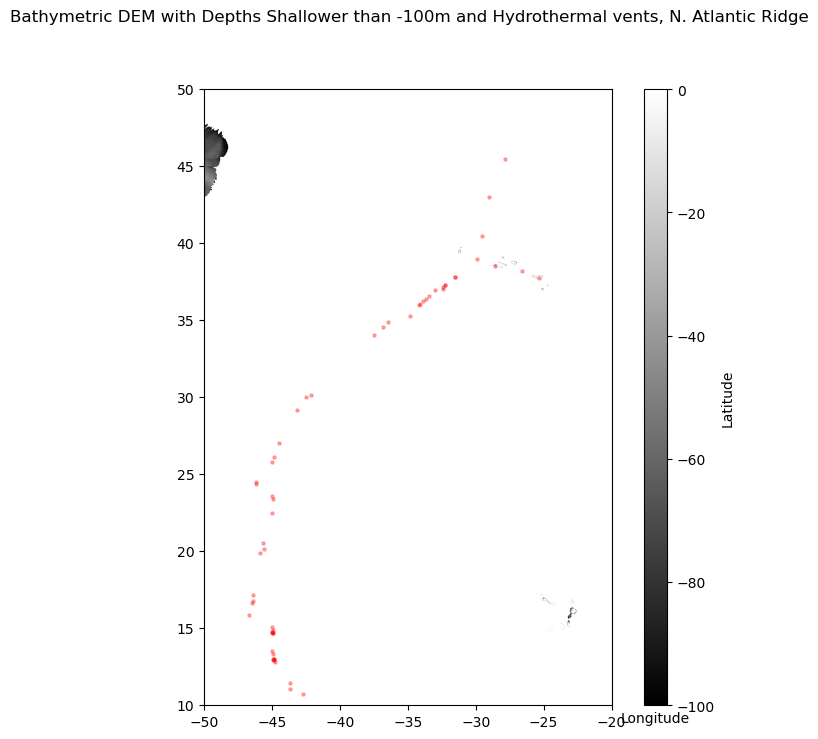

In [ ]:
### show both DEM and SHP where depth is filtered
with rasterio.open(dem_file) as src:
    dem = src.read(1)
    transform = src.transform

### define threshold depths
threshold_depth_min = -100 
threshold_depth_max = 0  

### mask out depths deeper than threshold_depth_min and shallower than 0m below sea level
dem_masked = np.where((dem >= threshold_depth_min) & (dem <= threshold_depth_max), dem, 0)

### mask for only showing azores 
azores_bounds = azores_bounds

### plot masked DEM
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(dem_masked, cmap='binary_r', extent=[transform[2], transform[2] + dem_masked.shape[1] * transform[0], transform[5] + dem_masked.shape[0] * transform[4], transform[5]])
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
plt.colorbar(im, cax=cax, label='Depth (m)')
fig.suptitle(f'Bathymetric DEM with Depths Shallower than {threshold_depth_min}m and Hydrothermal vents, N. Atlantic Ridge', ha='center')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

### add depth information when clicking on the plot
def get_depth_at_click(sel):
    x, y = sel.target  ### in map (longitude, latitude) coordinates
    col, row = ~transform * (x, y)  ### use the inverse transform to get raster indices
    col, row = int(col), int(row)

    ### check indices within bounds
    if 0 <= row < dem_masked.shape[0] and 0 <= col < dem_masked.shape[1]:
        depth = dem_masked[row, col]
        sel.annotation.set_text(f"Depth: {depth:.2f} m")
    else:
        sel.annotation.set_text("Clicked outside raster bounds.")

mplcursors.cursor().connect("add", get_depth_at_click)

### plot hydrothermal vents on top of DEM
vents_data_filtered.plot(ax=ax, color='red', alpha= 0.3, markersize=5, label='Hydrothermal Vents')

plt.show()


In [ ]:
### cape verde 25 17 to 21 14 